In [136]:
import pandas as pd

In [137]:
import seaborn as sns

In [138]:
import matplotlib.pyplot as plt

In [139]:
df = pd.read_csv('Sample - Superstore.csv', sep=';', encoding='ISO-8859-1')

In [140]:

df["Profit"] = pd.to_numeric(df["Profit"], errors='coerce')
df["Sales"] = pd.to_numeric(df["Sales"], errors='coerce')
df = df.dropna(subset=['Sales', 'Profit'])


In [141]:
df.head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11.08.2016,11.11.2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,419.136
1,2,CA-2016-152156,11.08.2016,11.11.2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.0,0.0,219.582
2,3,CA-2016-138688,6.12.2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.0,68.714
4,5,US-2015-108966,10.11.2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.2,25.164
5,6,CA-2014-115812,6.09.2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.0,141.694
7,8,CA-2014-115812,6.09.2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6.0,0.2,907.152
8,9,CA-2014-115812,6.09.2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3.0,0.2,57.825
9,10,CA-2014-115812,6.09.2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5.0,0.0,34.470
11,12,CA-2014-115812,6.09.2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.424,4.0,0.2,683.568
12,13,CA-2017-114412,4/15/2017,4/20/2017,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,...,28027,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.552,3.0,0.2,54.432


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7775 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         7775 non-null   int64  
 1   Order ID       7775 non-null   object 
 2   Order Date     7775 non-null   object 
 3   Ship Date      7775 non-null   object 
 4   Ship Mode      7775 non-null   object 
 5   Customer ID    7775 non-null   object 
 6   Customer Name  7775 non-null   object 
 7   Segment        7775 non-null   object 
 8   Country        7775 non-null   object 
 9   City           7775 non-null   object 
 10  State          7775 non-null   object 
 11  Postal Code    7775 non-null   int64  
 12  Region         7775 non-null   object 
 13  Product ID     7775 non-null   object 
 14  Category       7775 non-null   object 
 15  Sub-Category   7775 non-null   object 
 16  Product Name   7775 non-null   object 
 17  Sales          7775 non-null   float64
 18  Quantity     

In [143]:
df[["Quantity","Discount"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,7775.0,3.778264,2.177655,1.0,2.0,3.0,5.0,14.0
Discount,7775.0,0.170219,0.206657,0.0,0.0,0.2,0.2,0.8


In [144]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [145]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,419.136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.0,0.0,219.582
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.0,68.714
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.2,25.164
5,6,CA-2014-115812,2014-09-06,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.0,141.694


# Calculate total sales for each state and get the top 10

In [146]:
df.groupby("State")

In [147]:
top_10_sales=df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='State'>

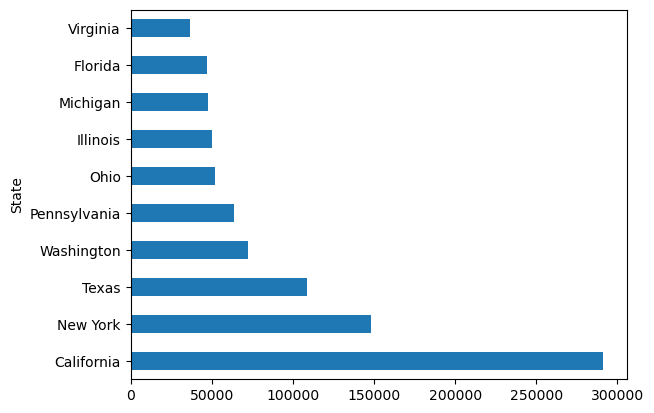

In [148]:
top_10_sales.plot.barh()

In [149]:
top_10_quantity=df.groupby("State")["Quantity"].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='State'>

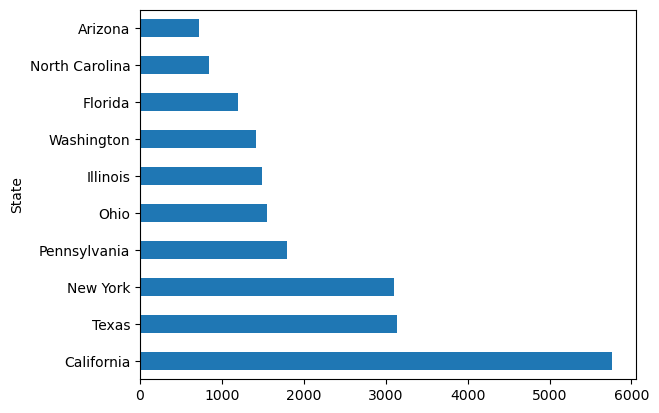

In [150]:
top_10_quantity.plot.barh()

# Calculate total sales and profit by year

In [151]:
df.groupby(df["Order Date"].dt.year)

In [152]:
annual_perf=df.groupby(df["Order Date"].dt.year).agg(Total_Revenue=("Sales","sum"),Order_Count=("Order ID","nunique")).reset_index()

In [153]:
annual_perf.rename(columns={"Sales":"Total_Revenue", "Order ID": "Order_Count"})

,Order Date,Total_Revenue,Order_Count
0,2014,266077.557,835
1,2015,287158.344,908
2,2016,339077.311,1157
3,2017,406794.046,1473


<Axes: xlabel='Order Date', ylabel='Total_Revenue'>

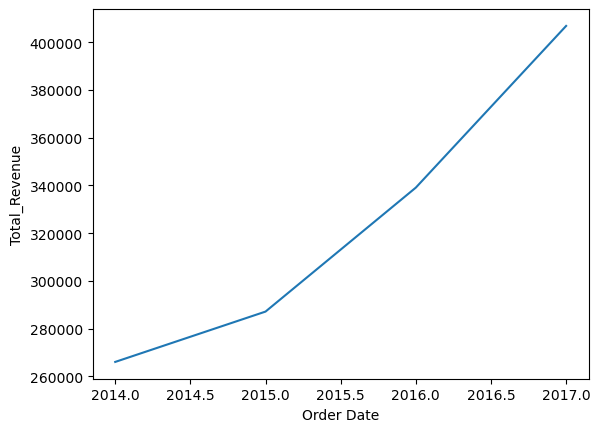

In [154]:
sns.lineplot(x="Order Date",y="Total_Revenue",data=annual_perf)

<Axes: xlabel='Order Date', ylabel='Order_Count'>

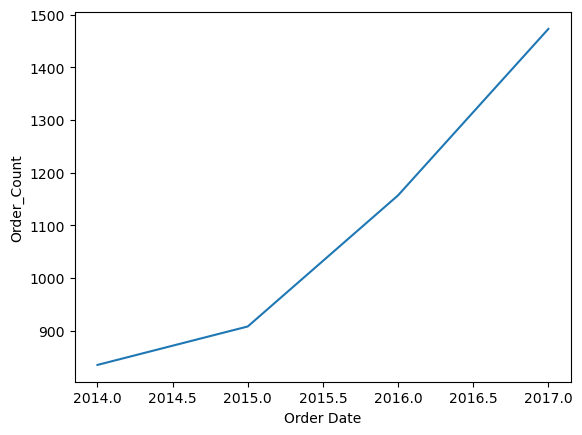

In [155]:
sns.lineplot(x="Order Date",y="Order_Count",data=annual_perf)

#  Calculate total profit by Year and Sub-Category

In [156]:
df["Year"]=df["Order Date"].dt.year

In [157]:
df.groupby("Year")[["Profit"]].sum().reset_index()

,Year,Profit
0,2014,152140.5234
1,2015,175180.1835
2,2016,188093.5788
3,2017,219835.4932


In [158]:
yearly_subcat_profit=df.groupby(["Year","Sub-Category"])[["Profit"]].sum()
yearly_subcat_profit

Profit
Year Sub-Category            
2014 Accessories   27663.1365
     Appliances    12161.0460
     Art            4831.5800
     Binders        3678.3442
     Bookcases       368.8710
...                       ...
2017 Paper         55463.0200
     Phones        31503.5946
     Storage       17303.3464
     Supplies        776.5512
     Tables        -8339.4980

[68 rows x 1 columns]

<Axes: xlabel='Profit', ylabel='Sub-Category'>

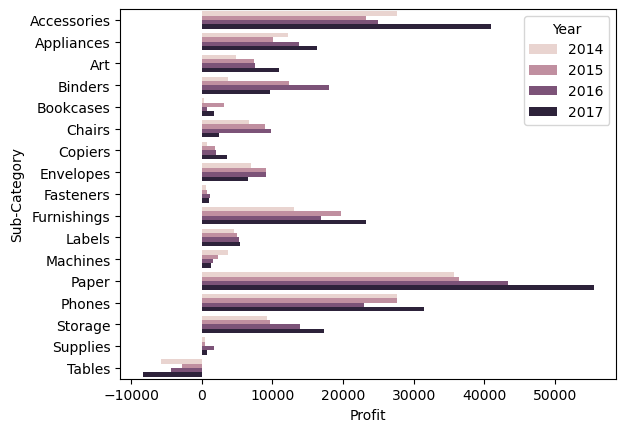

In [159]:
sns.barplot(x="Profit",y="Sub-Category",hue="Year",data=yearly_subcat_profit)

# Calculate total profit by Customer Segment

In [160]:
segment_profit=df.groupby("Segment")[["Profit"]].sum().reset_index()
segment_profit

,Segment,Profit
0,Consumer,392745.3302
1,Corporate,214134.6385
2,Home Office,128369.8102


In [161]:
total_profit=segment_profit[["Profit"]].sum()
total_profit

Profit    735249.7789
dtype: float64

In [162]:
segment_profit["Percentage"]=(segment_profit[["Profit"]]/total_profit*100).round(2)

In [163]:
segment_profit[["Percentage"]]

,Percentage
0,53.42
1,29.12
2,17.46


([<matplotlib.patches.Wedge at 0x1c98267b9d0>,
 [Text(-0.1178422005589938, 1.0936696099679346, 'Consumer'),
  Text(-0.4696939142092793, -0.9946796604710314, 'Corporate'),
  Text(0.9386375976779588, -0.5735498759701292, 'Home Office')])

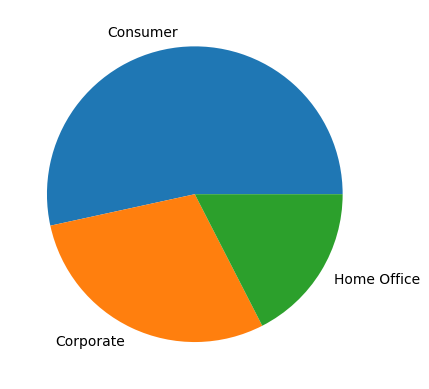

In [164]:
plt.pie(segment_profit["Profit"], labels=segment_profit["Segment"])

# Analyze the relationship between Shipping Duration and Profitability

In [189]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed', dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='mixed', dayfirst=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\1621508098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed', dayfirst=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\1621508098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='mixed', dayfirst=True)


In [190]:
df["Ship_Duration"]=(df["Ship Date"]-df["Order Date"]).dt.days
df["Ship_Duration"]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\2587504074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship_Duration"]=(df["Ship Date"]-df["Order Date"]).dt.days


12      5
14      4
15      4
16      7
23      2
       ..
9987    4
9988    4
9989    2
9990    5
9991    5
Name: Ship_Duration, Length: 4093, dtype: int64

In [191]:
anomalous_rows = df[(df["Ship_Duration"] < 0) | (df["Ship_Duration"] > 30)]
anomalous_rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Ship_Duration
6027,6028,CA-2017-136007,2017-02-23,2017-02-03,Standard Class,AC-10615,Ann Chong,Corporate,United States,Seattle,...,TEC-PH-10003589,Technology,Phones,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,71.96,5.0,0.2,25.186,2017,-20


In [192]:
df["Order Date"] = df["Order Date"].astype(str)
df["Ship Date"] = df["Ship Date"].astype(str)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\2259809351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order Date"] = df["Order Date"].astype(str)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\2259809351.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship Date"] = df["Ship Date"].astype(str)


In [193]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed', dayfirst=True, errors='coerce')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='mixed', dayfirst=True, errors='coerce')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\37429801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed', dayfirst=True, errors='coerce')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\37429801.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], format='mixed', dayfirst=True, errors='coerce')


In [194]:
df["Ship_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\2401692856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days


In [195]:
print("new_avg_duration:", df["Ship_Duration"].mean())
print("error_row_count:", len(df[df["Ship_Duration"] < 0]))

new_avg_duration: 3.677498167603225
error_row_count: 1


In [196]:
df["Ship_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days.abs()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10972\2816413723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ship_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days.abs()


In [197]:
df = df[df["Ship_Duration"] <= 20]

In [198]:
print(f"new_avg_duration: {df['Ship_Duration'].mean():.2f} gün")
print(f"total_clean_rows: {len(df)}")

new_avg_duration: 3.69 gün
total_clean_rows: 4093


In [199]:
duration_profit_analysis=df.groupby("Ship_Duration")["Profit"].mean().reset_index()
duration_profit_analysis

,Ship_Duration,Profit
0,0,100.926905
1,1,80.114195
2,2,102.958184
3,3,87.008131
4,4,92.326756
5,5,100.160391
6,6,88.786656
7,7,71.934966
8,20,25.186000


<Axes: xlabel='Ship_Duration', ylabel='Profit'>

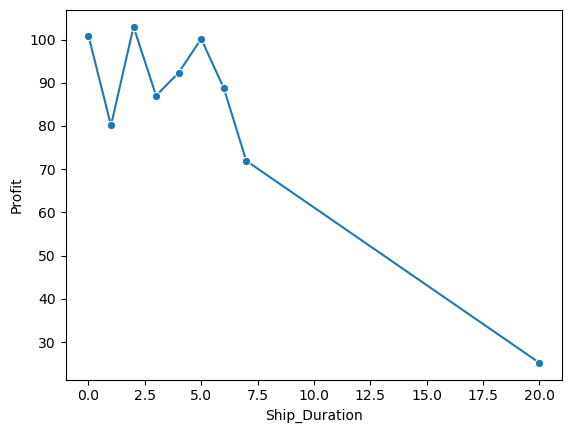

In [200]:
sns.lineplot(x="Ship_Duration",y="Profit",data=duration_profit_analysis,marker="o")

# Analyze product interest by region

In [201]:
regional_product_quantity=df.groupby(["Region","Sub-Category"])[["Quantity"]].sum().reset_index()
regional_product_quantity

,Region,Sub-Category,Quantity
0,Central,Accessories,311.0
1,Central,Appliances,156.0
2,Central,Art,276.0
3,Central,Binders,576.0
4,Central,Bookcases,49.0
...,...,...,...
62,West,Paper,740.0
63,West,Phones,489.0
64,West,Storage,440.0
65,West,Supplies,97.0


<Axes: xlabel='Quantity', ylabel='Sub-Category'>

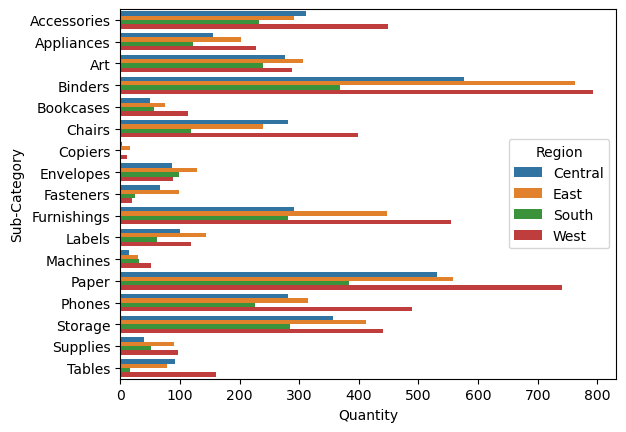

In [178]:
sns.barplot(data=regional_product_quantity, x="Quantity", y="Sub-Category", hue="Region")

# Analyze the impact of discounts on profitability

In [179]:
discount_profit=df.groupby("Discount")[["Profit"]].mean().reset_index()
discount_profit

,Discount,Profit
0,0.00,196.674020
1,0.10,320.235706
2,0.15,30.991957
3,0.20,76.244690
4,0.30,-214.944782
5,0.32,-65.355333
6,0.40,-188.701529
7,0.50,-324.170571
8,0.60,-115.238108
9,0.70,-107.449102


<Axes: xlabel='Discount', ylabel='Profit'>

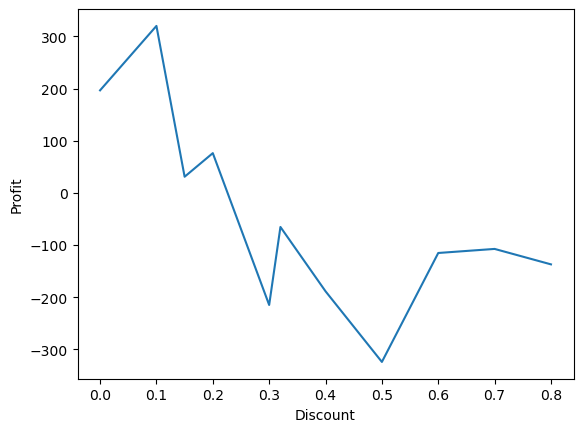

In [180]:
sns.lineplot(discount_profit,x="Discount",y="Profit")

# Calculate total product quantity by City, Year, and Sub-Category

In [181]:
df.groupby(["City",df["Order Date"].dt.year])["Sales"]

In [182]:
city_yearly_demand=df.groupby(["City",df["Order Date"].dt.year,"Sub-Category"])[["Sales"]].sum().reset_index()
city_yearly_demand.columns=["City","Year","Sub-Category","Total Sales"]
city_yearly_demand

,City,Year,Sub-Category,Total Sales
0,Akron,2014,Binders,5.742
1,Akron,2014,Furnishings,149.232
2,Akron,2014,Paper,15.936
3,Akron,2015,Accessories,71.976
4,Akron,2015,Art,14.352
...,...,...,...,...
2360,York,2016,Chairs,422.058
2361,York,2016,Storage,254.352
2362,Yucaipa,2015,Art,50.800
2363,Yuma,2016,Accessories,185.528


In [183]:
top_5_city=df.groupby("City")["Sales"].sum().reset_index().sort_values(by="Sales",ascending=False).head(5)
top_5_city

,City,Sales
259,New York City,64121.124
206,Los Angeles,58552.954
344,San Francisco,41534.055
352,Seattle,35276.186
293,Philadelphia,24033.585


In [184]:
top_5_city_names = top_5_city["City"].tolist()
top_5_city_names

['New York City', 'Los Angeles', 'San Francisco', 'Seattle', 'Philadelphia']

In [185]:
top_5_data = sehir_yil_ürün[sehir_yil_ürün["City"].isin(top_5_city_names)]

In [186]:
top_5_yearly = top_5_data.pivot_table(index=["City","Sub-Category"],
                                      columns="Year", 
                                      values="Total Sales", 
                                      aggfunc="sum")

In [187]:
top_5_yearly 

Year                          2014      2015      2016      2017
City        Sub-Category                                        
Los Angeles Accessories    826.040  1789.800  1921.550  1300.050
            Appliances     150.880  1990.900   281.450   313.450
            Art            111.980   288.450   164.340   295.080
            Binders        806.064   490.192   184.544  1492.184
            Bookcases      907.664       NaN   838.831   344.981
...                            ...       ...       ...       ...
Seattle     Paper          136.820   227.640   207.260   209.760
            Phones         383.960   703.160   375.824  1618.888
            Storage       1190.150   199.740  1461.250  3287.250
            Supplies       238.620       NaN    29.560    64.400
            Tables         730.200   171.960  2862.420  1154.960

[80 rows x 4 columns]

<Axes: xlabel='Year', ylabel='City-Sub-Category'>

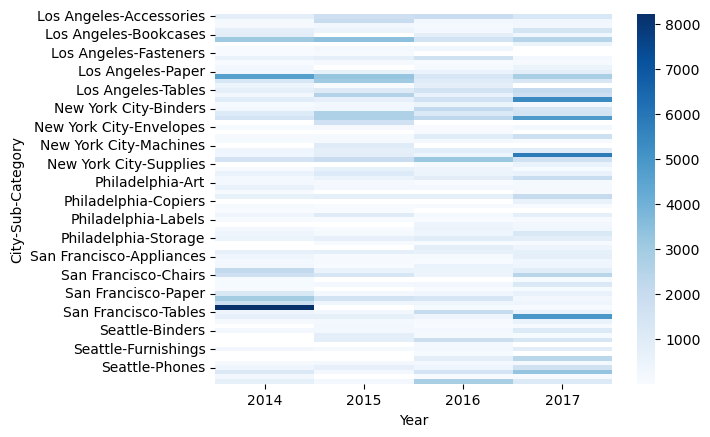

In [188]:
sns.heatmap(top_5_yearly ,fmt = ".0f",cmap="Blues")